In [11]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

# Convert Text --> numerical features
from sklearn.feature_extraction.text import TfidfVectorizer

# first Classifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
      accuracy_score,
      precision_score,
      recall_score,
      f1_score,
      confusion_matrix,
      classification_report
)

print("Libraries imported successfully")






Libraries imported successfully


# # Downloading stopwords like : the is, am are,

In [12]:

nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prade\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
stop_words = set(stopwords.words("english"))
print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


In [14]:
df = pd.read_csv("spam.csv",encoding="latin-1") 


In [15]:
# Remove Unnecessary Columns
df = df[["v1", "v2"]]

df.columns = ["label", "message"]

print(df.head())
print(df.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [16]:
print(df.columns.tolist())

['label', 'message']


# Understand dataset

In [17]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape: (5572, 2)

Columns:
Index(['label', 'message'], dtype='str')

Data types:
label      str
message    str
dtype: object

Missing values:
label      0
message    0
dtype: int64

Duplicate rows:
403


In [19]:
# Class Distribution Spam Vs Ham

class_counts = df['label'].value_counts()

print("Class Counts:")
print(class_counts)

Class Counts:
label
ham     4825
spam     747
Name: count, dtype: int64


In [21]:
class_percentage = df['label'].value_counts(normalize=True) * 100

print("\n Class Percentage:")
print(class_percentage)


 Class Percentage:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


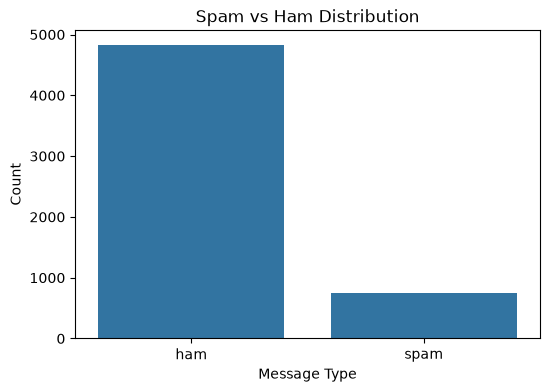

In [23]:
# Class Distribution chart 
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

# Text Preprocessing

In [47]:
# Using Preprocessed function 
def preprocess_text (text):
    # Convert text to lowercase
    text = text.lower()  

    # Remove punctuation
    text = text.translate(
    str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Split text into words
    words = text.split()

    # Remove stopwords
    words = [
          word for word in words 
          if word not in stop_words
    ]


    # Join words back together
    text = " ".join(words)

    return text
    

In [49]:
df['clean_message'] = df['message'].apply(preprocess_text)

In [51]:
# We remove unnecessary noise so that model can focuses on important words 
df[['message', 'clean_message']].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word back id like fu...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


# Train-Test split

In [52]:
X = df["clean_message"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= 42,
    stratify=y 
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))  

Training samples: 4457
Testing samples: 1115


# Apply TF-IDF

In [53]:
tfidf = TfidfVectorizer()

X_train = tfidf.fit_transform(X_train_text)  # Training 
X_test = tfidf.transform(X_test_text)        # Testing

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)


Training TF-IDF shape: (4457, 7468)
Testing TF-IDF shape: (1115, 7468)


# TF-IDF Feature Extraction
  TF-IDF is used to convert text message into numerical features that  machine lea
  learning model can understand.

  # Term frequence (TF) measures how frequenctly a words appears in a
    particular message.
  # Inverse  Document Frequence (IDF)  reduces importance of words that appears in many messages.
  # As a result the words which such as "the" receive lower weight, whil  more informative words such as "free" , "prize", "winner", receives higher wieghts in spam-related message. 

# > Convert labels to Numbers 

In [54]:
y_train = y_train.map({
    "ham": 0,
    "spam": 1
})

y_test = y_test.map({
    "ham":0,
    "spam":1,
})


In [55]:
print(y_train.head())

184     0
2171    0
5422    0
4113    0
4588    0
Name: label, dtype: int64


#  1 -- Multionomial Naive Bayes Classifier

In [56]:
# Naive bayes works on sentimental analysis and probablities by giving +ve, -ve and neutral points to the problem.  
nb_model = MultinomialNB()

nb_model.fit(X_train,y_train) 
y_pred_nb = nb_model.predict(X_test)

# Classifier 2 -- Logisitc Regression 

In [57]:
lr_model = LogisticRegression (
    max_iter = 1000
)

lr_model.fit(X_train,y_train) 
y_pred_lr = lr_model.predict(X_test)

# Evaluation matrix - Naive Bayes 

In [58]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(y_test, y_pred_nb)

recall_nb = recall_score(y_test, y_pred_nb)

f1_nb = f1_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes")

print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1-Score :", f1_nb)

Multinomial Naive Bayes
Accuracy : 0.9632286995515695
Precision: 0.990909090909091
Recall   : 0.7315436241610739
F1-Score : 0.8416988416988417


# Confusion matrix

<Axes: >

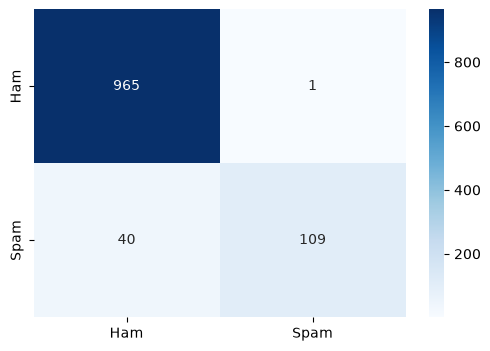

In [59]:
cm_nb = confusion_matrix(y_test, y_pred_nb) 

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham" , "Spam"],
)

## Why is Recall Particularly Important for Spam Detection?

Recall is particularly important in spam detection because it measures how many actual spam messages are correctly identified as spam.

A false negative occurs when an actual spam message is incorrectly classified as ham. This can allow unwanted, fraudulent, or potentially harmful messages to reach the user's inbox.

Therefore, a high recall helps the system detect a larger proportion of actual spam messages.

However, precision is also important because legitimate messages should not be incorrectly classified as spam.